In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [146]:
df = pd.read_csv("placement.csv")
print(df.shape)
df.head()

(100, 4)


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [147]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.2 KB


In [148]:
df = df.iloc[:, 1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


### Steps
0. Preprocess + EDA + Feature Selection
1. Extract input and output cols
2. Scale the values
3. Train test split
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model

Text(0, 0.5, 'IQ')

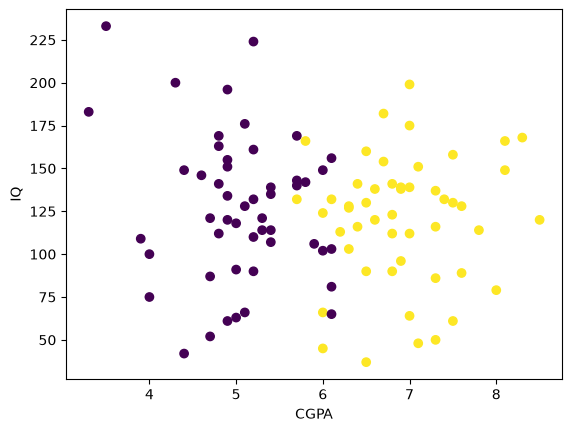

In [149]:
plt.scatter(df["cgpa"], df["iq"], c=df["placement"])
plt.xlabel("CGPA")
plt.ylabel("IQ")

In [150]:
x = df.iloc[:, 0:2]
y = df.iloc[:, 2]

print("Shape of X:", x.shape)
print("Shape of Y:",y.shape)

Shape of X: (100, 2)
Shape of Y: (100,)


In [151]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [152]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [153]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

print("X_test: ", x_test.shape)
print("X_train: ", x_train.shape)
print("Y_test: ", y_test.shape)
print("Y_train: ", y_train.shape)

X_test:  (20, 2)
X_train:  (80, 2)
Y_test:  (20,)
Y_train:  (80,)


In [154]:
x_train

,cgpa,iq
52,7.0,175.0
76,4.9,155.0
10,6.0,45.0
22,4.9,120.0
26,7.0,199.0
...,...,...
8,6.1,156.0
64,7.0,64.0
38,6.5,160.0
80,4.9,196.0


In [155]:
y_train

52    1
76    0
10    1
22    0
26    1
     ..
8     0
64    1
38    1
80    0
83    1
Name: placement, Length: 80, dtype: int64

In [156]:
x_test

,cgpa,iq
56,6.1,65.0
23,4.7,87.0
46,5.3,114.0
55,7.8,114.0
75,4.8,169.0
50,3.5,233.0
47,5.2,161.0
62,6.0,102.0
81,5.4,107.0
14,6.1,103.0


In [157]:
y_test

56    0
23    0
46    0
55    1
75    0
50    0
47    0
62    0
81    0
14    0
99    1
12    0
82    1
98    1
27    1
25    0
33    0
37    1
53    1
0     1
Name: placement, dtype: int64

In [158]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_train

array([[ 0.88451896,  1.30056291],
       [-0.96372961,  0.79215816],
       [ 0.00440059, -2.00406799],
       [-0.96372961, -0.09755016],
       [ 0.88451896,  1.91064861],
       [-0.78770594,  1.32598315],
       [-2.371919  ,  1.50392481],
       [-0.52367043,  0.2837534 ],
       [-1.84384798, -0.37717278],
       [ 0.35644794,  0.43627483],
       [-0.25963492,  1.14804148],
       [ 0.70849528, -0.86015729],
       [-1.40378879, -2.0803287 ],
       [-0.78770594,  0.10581174],
       [ 0.09241243, -1.08893943],
       [ 1.14855447, -0.96183824],
       [-1.05174145,  0.99552006],
       [ 1.41258998,  0.10581174],
       [ 0.79650712, -0.70763587],
       [-1.05174145, -0.30091206],
       [-1.05174145,  0.43627483],
       [ 0.53247161, -0.09755016],
       [ 1.32457814, -1.59734418],
       [-0.6996941 ,  0.20749269],
       [-1.40378879,  0.63963673],
       [ 0.2684361 ,  0.0803915 ],
       [ 1.85264916,  1.07178077],
       [ 0.62048345,  0.76673792],
       [ 0.88451896,

In [159]:
x_test = scaler.transform(x_test)

In [160]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

clf.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [161]:
y_pred = clf.predict(x_test)
y_pred

array([1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1])

In [162]:
y_test

56    0
23    0
46    0
55    1
75    0
50    0
47    0
62    0
81    0
14    0
99    1
12    0
82    1
98    1
27    1
25    0
33    0
37    1
53    1
0     1
Name: placement, dtype: int64

In [163]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8